In [2]:
from pathlib import Path
from torchvision import datasets

In [3]:
DATA_DIR= Path('../raw-img')

print(DATA_DIR.exists())
print(DATA_DIR.resolve())

True
C:\Users\David Danell\PyTorch\PyTorch\CNN_pracice\raw-img


In [4]:
dataset= datasets.ImageFolder(root=DATA_DIR)

print('Antal bilder:', len(dataset))
print('klasser:', dataset.classes)
print('klasser till index:', dataset.class_to_idx)

Antal bilder: 26179
klasser: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
klasser till index: {'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


SKAPA LABELS OCH INDEX


In [5]:
indices=[]
labels=[]

for i, sample in enumerate(dataset.samples):
    image_path, label=sample
    
    indices.append(i)
    labels.append(label)

print(indices[0], labels[0])

print("Antal indices:", len(indices))
print("Antal labels:", len(labels))
print("Antal bilder i dataset:", len(dataset))

print("Första 10 indices:", indices[:10])
print("Första 10 labels:", labels[:10])

0 0
Antal indices: 26179
Antal labels: 26179
Antal bilder i dataset: 26179
Första 10 indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Första 10 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
from collections import Counter

print("Antal labels:", len(labels))
print("Första 10 labels:")
print(labels[:10])

label_counts = Counter(labels)

print("\nAntal unika labels:", len(label_counts))
print("\n10 vanligaste labels:")
for label, count in label_counts.most_common(10):
    print(label, ":", count)

print("\n10 minst vanliga labels:")
for label, count in label_counts.most_common()[-10:]:
    print(label, ":", count)

Antal labels: 26179
Första 10 labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Antal unika labels: 10

10 vanligaste labels:
0 : 4863
8 : 4821
4 : 3098
1 : 2623
3 : 2112
6 : 1866
9 : 1862
7 : 1820
5 : 1668
2 : 1446

10 minst vanliga labels:
0 : 4863
8 : 4821
4 : 3098
1 : 2623
3 : 2112
6 : 1866
9 : 1862
7 : 1820
5 : 1668
2 : 1446


In [ ]:
from sklearn.model_selection import train_test_split

train_indices, temp_indices, train_labels, temp_labels= train_test_split(
    indices,
    labels, 
    test_size= 0.30, 
    stratify=labels,
    random_state=0
)

valid_indices, test_indices, valid_labels, test_labels= train_test_split(
    temp_indices,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=0
)



([672,
  1901,
  19275,
  8483,
  21513,
  13185,
  10437,
  14203,
  19242,
  7047,
  2627,
  20439,
  836,
  22449,
  1592,
  25727,
  10680,
  17946,
  16569,
  12268,
  14348,
  15486,
  6310,
  5218,
  11776,
  11891,
  8718,
  12151,
  365,
  575,
  14442,
  20801,
  20102,
  3325,
  16348,
  16772,
  17210,
  18510,
  11689,
  25011,
  13710,
  13746,
  17148,
  24479,
  19377,
  3594,
  24786,
  23790,
  25345,
  12300,
  23402,
  20324,
  9105,
  24836,
  24145,
  22724,
  23045,
  8401,
  22551,
  16081,
  15185,
  11520,
  4739,
  9984,
  3936,
  19359,
  6592,
  17093,
  23448,
  23929,
  19869,
  1358,
  24538,
  1465,
  379,
  11175,
  19112,
  9032,
  8061,
  8060,
  23023,
  8491,
  10752,
  11879,
  21782,
  18389,
  11816,
  13944,
  16484,
  20676,
  5847,
  12158,
  21927,
  22045,
  20140,
  13982,
  16851,
  10169,
  19919,
  12968,
  15289,
  12550,
  8771,
  8511,
  7192,
  7115,
  8261,
  22263,
  24152,
  3170,
  9960,
  26166,
  14842,
  13816,
  8204,
  1083

In [8]:
from torch.utils.data import Subset


train_dataset= Subset(dataset, train_indices)
valid_dataset= Subset(dataset, valid_indices)
test_dataset= Subset(dataset, test_indices)

print("Train dataset:", len(train_dataset))
print("Valid dataset:", len(valid_dataset))
print("Test dataset:", len(test_dataset))



Train dataset: 18325
Valid dataset: 3927
Test dataset: 3927


TRANSFORMERING


In [9]:
from torchvision import transforms

Pipeline? :

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
eval_transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

skapa dataseten med transform pipeline:

In [12]:
from torchvision import datasets
from torch.utils.data import Subset


train_dataset_full= datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

valid_data_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)

test_data_full= datasets.ImageFolder(
    root= DATA_DIR,
    transform=eval_transform
)

gör om dataseten med transform, vi gjorde detta om igen för att vi inte vill göra samma transform på all data utan bara train datan 

In [13]:
train_dataset= Subset(train_dataset_full, train_indices)
valid_dataset= Subset(valid_data_full, valid_indices)
test_dataset= Subset(test_data_full, test_indices)

In [14]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)
print(train_dataset_full.classes[label])


<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0
cane


SKAPA DATALOADER- detta gör vi för att kunna ge modellen datan i omgångar så gpu inte exploderar samt kunna shuffla labels så modellen inte blir lika overfittad

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE= 32

train_dataloader= DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0
)

valid_loader= DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

test_dataloader= DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

In [16]:
images, labels = next(iter(train_dataloader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Första 10 labels:", labels[:10])



Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Första 10 labels: tensor([0, 0, 6, 8, 5, 8, 6, 6, 8, 4])


In [17]:
print(train_dataset_full.classes)
print(train_dataset_full.class_to_idx)

['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
{'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


In [18]:
for label in labels[:10]:
    print(train_dataset_full.classes[label])

cane
cane
mucca
ragno
gatto
ragno
mucca
mucca
ragno
gallina


TRAINING RESNET18

In [19]:
import torch
import torch.nn as nn

from torchvision import models
from torchvision.models import ResNet18_Weights

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [21]:
weights = ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

model = model.to(device)

In [22]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


sätt sista lagret för att passa vår data


In [25]:
num_classes= 10

model.fc= nn.Linear(
    in_features=model.fc.in_features,
    out_features= num_classes
)

model= model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [32]:
images, labels= next(iter(train_dataloader))

images= images.to(device)
labels= labels.to(device)

outputs= model(images)

print(outputs.shape)

torch.Size([32, 10])


trän modellen på vår data, (bara sista lagret)

gör den redo bara sista lagret får tränas

loss FN

optimizer

In [37]:
for param in model.parameters():
    param.requires_grad= False


for param in model.fc.parameters():
    param.requires_grad= True

criterion = nn.CrossEntropyLoss()

optimizer= torch.optim.Adam(
    model.fc.parameters(),
    lr= 0.001
)

In [38]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


training loop?/ funktion

1. Flyttar bilder och labels till device
2. Nollställer gamla gradients
3. Kör bilderna genom modellen
4. Räknar loss
5. Backpropagation
6. Uppdaterar sista lagrets vikter
7. Räknar accuracy

In [40]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predicted_labels = outputs.argmax(dim=1)

        correct_predictions += (predicted_labels == labels).sum().item()
        total_predictions += labels.size(0)

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions

    return epoch_loss, epoch_accuracy

In [41]:
train_loss, train_acc = train_one_epoch(
    model=model,
    train_loader=train_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)

print("Train loss:", train_loss)
print("Train accuracy:", train_acc)

Train loss: 0.6868375656191682
Train accuracy: 0.790668485675307


valid funktion

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predicted_labels = outputs.argmax(dim=1)

            correct_predictions += (predicted_labels == labels).sum().item()
            total_predictions += labels.size(0)

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions

    return epoch_loss, epoch_accuracy

In [43]:
valid_loss, valid_acc = evaluate(
    model=model,
    data_loader=valid_loader,
    criterion=criterion,
    device=device
)

print("Valid loss:", valid_loss)
print("Valid accuracy:", valid_acc)

Valid loss: 0.21006738333786174
Valid accuracy: 0.9381207028265852


TRAINNING LOOP

In [44]:
NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_dataloader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_acc = evaluate(
        model=model,
        data_loader=valid_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Valid loss: {valid_loss:.4f} | Valid acc: {valid_acc:.4f}")
    print("-" * 50)

Epoch 1/5
Train loss: 0.4537 | Train acc: 0.8512
Valid loss: 0.1693 | Valid acc: 0.9430
--------------------------------------------------
Epoch 2/5
Train loss: 0.4454 | Train acc: 0.8525
Valid loss: 0.1646 | Valid acc: 0.9486
--------------------------------------------------
Epoch 3/5
Train loss: 0.4316 | Train acc: 0.8570
Valid loss: 0.1668 | Valid acc: 0.9460
--------------------------------------------------
Epoch 4/5
Train loss: 0.4227 | Train acc: 0.8590
Valid loss: 0.1589 | Valid acc: 0.9483
--------------------------------------------------
Epoch 5/5
Train loss: 0.4190 | Train acc: 0.8607
Valid loss: 0.1614 | Valid acc: 0.9460
--------------------------------------------------


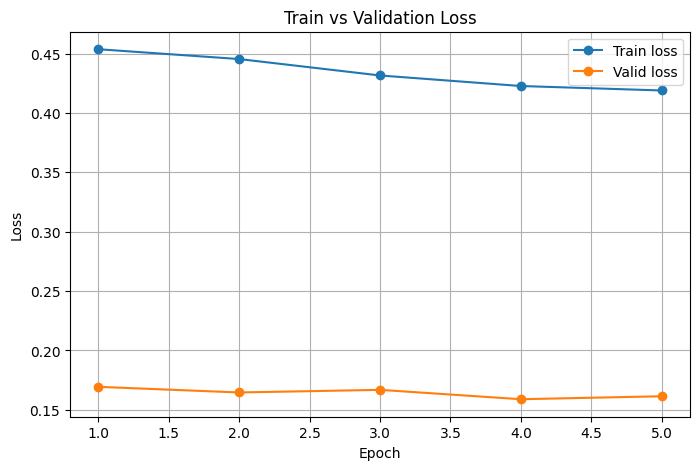

In [45]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["valid_loss"], marker="o", label="Valid loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

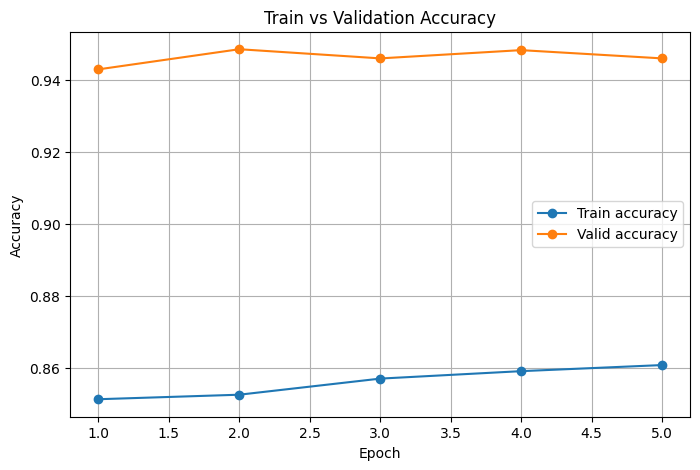

In [46]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
plt.plot(epochs, history["valid_acc"], marker="o", label="Valid accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

UTVERDERING

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.inference_mode():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

        all_preds.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

NameError: name 'model' is not defined

CLASSIFICATION REPORT

In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=valid_data_full.classes
))

              precision    recall  f1-score   support

        cane       0.96      0.94      0.95       729
     cavallo       0.93      0.92      0.93       393
    elefante       0.99      0.97      0.98       217
    farfalla       0.99      0.95      0.97       317
     gallina       0.99      0.96      0.97       465
       gatto       0.92      0.97      0.94       250
       mucca       0.85      0.88      0.86       280
      pecora       0.85      0.92      0.88       273
       ragno       0.96      0.99      0.98       723
  scoiattolo       0.98      0.91      0.95       280

    accuracy                           0.95      3927
   macro avg       0.94      0.94      0.94      3927
weighted avg       0.95      0.95      0.95      3927



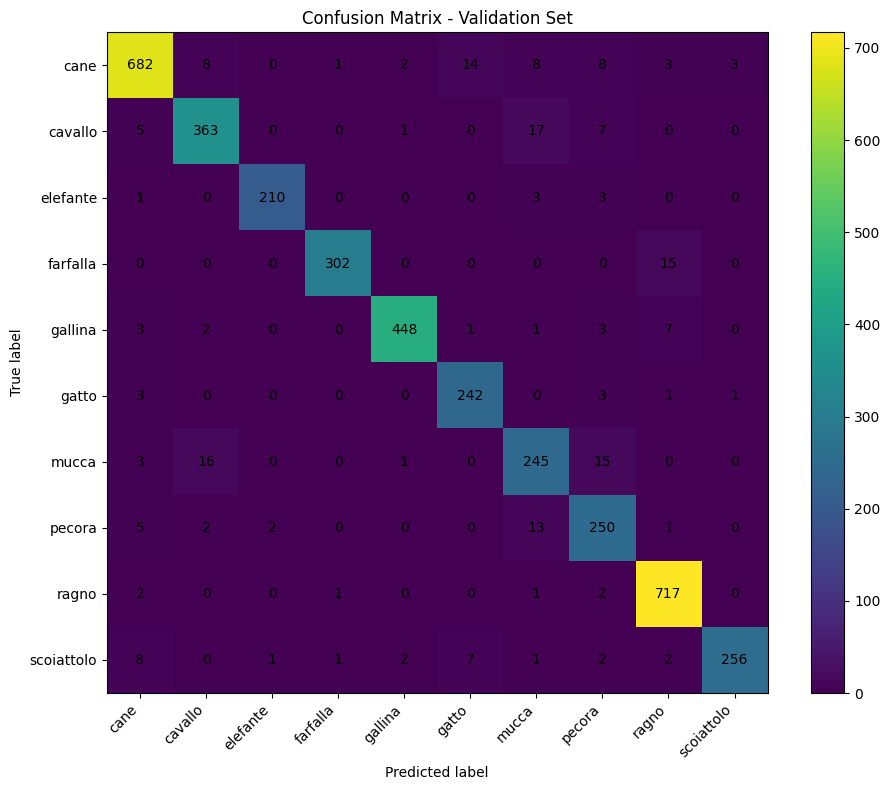

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

class_names = valid_data_full.classes

plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
test_preds = []
test_labels = []

model.eval()

with torch.inference_mode():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

        test_preds.extend(predicted_labels.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

In [52]:
print(classification_report(
    test_labels,
    test_preds,
    target_names=test_data_full.classes
))

              precision    recall  f1-score   support

        cane       0.96      0.95      0.95       730
     cavallo       0.94      0.95      0.94       394
    elefante       0.99      0.95      0.97       217
    farfalla       0.99      0.94      0.96       317
     gallina       0.98      0.97      0.98       464
       gatto       0.94      0.98      0.96       250
       mucca       0.90      0.88      0.89       280
      pecora       0.86      0.95      0.90       273
       ragno       0.96      1.00      0.98       723
  scoiattolo       0.98      0.92      0.95       279

    accuracy                           0.95      3927
   macro avg       0.95      0.95      0.95      3927
weighted avg       0.95      0.95      0.95      3927



SPARA MODELLEN

In [ ]:
from pathlib import Path

MODEL_DIR= Path('../models')

MODEL_DIR.mkdir(exist_ok=True)



In [58]:
model_path= MODEL_DIR / 'resnet18_animal10.pth'

checkpoint= {
    'model_state_dict': model.state_dict(),
    'class_names': train_dataset_full.classes,
    'class_to_idx': train_dataset_full.class_to_idx,
    'model_name': 'resnet18',
    'num_classes': len(train_dataset_full.classes)
}

torch.save(checkpoint, model_path)

print('modellen sparad till:', model_path)

modellen sparad till: ..\models\resnet18_animal10.pth


In [59]:
print(model_path.exists())
print(model_path.resolve())

True
C:\Users\David Danell\PyTorch\PyTorch\CNN_pracice\models\resnet18_animal10.pth


LAdda in modellen

In [61]:
checkpoint = torch.load("../models/resnet18_animal10.pth", map_location=device)

print(checkpoint.keys())
print(checkpoint["class_names"])
print(checkpoint["model_name"])
print(checkpoint["num_classes"])

dict_keys(['model_state_dict', 'class_names', 'class_to_idx', 'model_name', 'num_classes'])
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
resnet18
10


In [62]:
loaded_model = models.resnet18(weights=None)

num_features = loaded_model.fc.in_features
num_classes = checkpoint["num_classes"]

loaded_model.fc = nn.Linear(num_features, num_classes)

In [63]:
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model = loaded_model.to(device)
loaded_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
images, labels = next(iter(test_dataloader))

images = images.to(device)

with torch.inference_mode():
    outputs = loaded_model(images)

print(outputs.shape)

torch.Size([32, 10])


In [65]:
predict_transform = eval_transform

In [ ]:
from PIL import Image
import torch

def predict_image(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert("RGB")

    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.inference_mode():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_index = torch.max(probabilities, dim=1)

    predicted_index = predicted_index.item()
    confidence = confidence.item()

    predicted_class = class_names[predicted_index]

    return predicted_class, confidence

In [80]:
test_image_path = dataset.samples[0][0]

predicted_class, confidence = predict_image(
    image_path=test_image_path,
    model=loaded_model,
    transform=predict_transform,
    class_names=checkpoint["class_names"],
    device=device
)

print("Predicted class:", predicted_class)
print("Confidence:", confidence)
print("Actual class:", dataset.classes[dataset.samples[0][1]])

Predicted class: cane
Confidence: 0.9904298186302185
Actual class: cane


In [78]:
italian_to_english = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [81]:
english_class = italian_to_english[predicted_class]

print("Prediction:", english_class)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: dog
Confidence: 99.04 %
